# Post-Treatement of the data
The aim of this notebook is to import the different simulations, and compute the different indices of quality as well as the volume.  
The indices we calculate are the following for the synthetic :
1. Sum of the error 
2. Absolute sum of the error
3. Normalized Sum
4. Standard Deviation
5. Mean

For the real data, we just compute the volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os
import time
#from matplotlib.backends.backend_pdf import PdfPages
exec(open('../functions/03_indice_calculation_functions.py').read())


## Simulation output

In [2]:
def indice_dataframe(simu_sets_paths,typeSimu='mps'):
    '''
    Input: 
    simu_sets_paths : path to the folder containing the different folder set of simulation.
    typeSimu : 'mps' or 'sgs'for mps and sgs simulations - 'krig' for kriging estimate.
    output : A list of dataframe, one dataframe for each simulations sets.
    '''

    all_output = []
    real_vol   = []
    type_sim   = ['MPS','GRF']
    simulation_name = sorted(os.listdir(simu_sets_paths))[:]
    
    
    if typeSimu == 'mps' or typeSimu == 'sgs':
        #It goes through each set of simulation
        for name in simulation_name:

            with open(simu_sets_paths+name,'rb') as file:
                trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)

            trueMNT += trend_cut
            for i, simus in enumerate(simu_sets):        
                if np.all(simus != None):           
                    simus += trend_cut
                    indice_out = indice_calculationV(trueMNT, simus, typeSimu)
                    all_output.append([name[:-7],trueMNT, type_sim[i]]+indice_out)
                    
    elif typeSimu =='krig':               
        for name in simulation_name:
            with open(simu_sets_paths+name,'rb') as file:
                trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)
                
            trueMNT      += trend_cut
            simu_sets[0] += trend_cut

            indice_out = indice_calculationV(trueMNT, simu_sets, typeSimu)
            all_output.append([name[:-7],trueMNT, 'KRIG']+indice_out)
    
    else:
        print('Type error !')


                 
    results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','TrueMNT','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','RealVolume'])
    
    return results_frame

|        | n  | t     | f   |
|--------|----|-------|-----|
| Set 00 | 6  | 0.01  | 0.1 |
| Set 01 | 6  | 0.01  | 0.5 |
| Set 02 | 6  | 0.005 | 0.1 |
| Set 03 | 6  | 0.005 | 0.5 |
| Set 04 | 12 | 0.01  | 0.1 |
| Set 05 | 12 | 0.01  | 0.5 |
| Set 06 | 12 | 0.005 | 0.1 |
| Set 07 | 12 | 0.005 | 0.5 |
| Set 08 | 24 | 0.01  | 0.1 |
| Set 09 | 24 | 0.01  | 0.5 |
| Set 10 | 24 | 0.005 | 0.1 |
| Set 11 | 24 | 0.005 | 0.5 |

### MPS simulation

In [8]:
path_sets_mps = 'K:/projects/2019_tsanfleuron/output_simulation/800_3l_ss_bord/mps/'
path_sets_mps = '../simulation_outputs/800_3l_ss_bord/mps/'
#path_sets_mps = '../simulation_outputs/alexis_parameters/'
list_sets_mps = sorted(os.listdir(path_sets_mps))[:]
list_sets_mps

['simulation_set_00',
 'simulation_set_01',
 'simulation_set_02',
 'simulation_set_03',
 'simulation_set_04',
 'simulation_set_05',
 'simulation_set_06',
 'simulation_set_07',
 'simulation_set_08',
 'simulation_set_09',
 'simulation_set_10',
 'simulation_set_11']

In [6]:
with open(path_sets_mps+list_sets_mps[0]+'/simulation_realisation00.pickle','rb') as d:
    trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(d)

FileNotFoundError: [Errno 2] No such file or directory: '../simulation_outputs/800_3l_ss_bord/mpssimulation_set_00/simulation_realisation00.pickle'

In [9]:
all_results_mps = []
for name_set in list_sets_mps:
    all_results_mps.append(indice_dataframe(path_sets_mps+name_set+'/'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:156: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:156: RuntimeWarning: invalid value encountered in true_divide


In [10]:
all_results_mps[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,RealVolume
0,simulation_realisation00,"[[2569.7632, 2569.1992, 2568.8105, 2568.579, 2...",MPS,2.088257,11.514370,1.223580,"[[2569.7631835937495, 2569.19921875, 2568.8105...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8810275.583984407, 8429298.713134795, 8351156...",8961644.0
1,simulation_realisation01,"[[2611.3545, 2610.4736, 2609.5251, 2608.9705, ...",MPS,1.806157,10.214630,1.232506,"[[2611.3544921875, 2610.4736328125, 2609.52514...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[9527878.155273467, 10350607.927246116, 978929...",10099488.0
2,simulation_realisation02,"[[2465.7305, 2465.3088, 2465.0427, 2464.927, 2...",MPS,1.640948,12.879313,1.381409,"[[2465.73046875, 2465.3088378906245, 2465.0427...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14918217.894531285, 14684750.647949236, 16995...",15122563.0
3,simulation_realisation03,"[[2400.5906, 2400.1926, 2399.8137, 2399.409, 2...",MPS,-1.829833,14.118934,1.358254,"[[2400.590576171875, 2400.1926269531245, 2399....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13307528.277587911, 13907432.37792971, 152844...",14120233.0
4,simulation_realisation04,"[[2440.6196, 2440.6907, 2440.63, 2440.4792, 24...",MPS,1.848191,12.348583,1.344570,"[[2440.61962890625, 2440.690673828125, 2440.62...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14943529.765136732, 14613832.871337915, 14530...",14846813.0
5,simulation_realisation05,"[[2393.1646, 2392.6743, 2391.9502, 2391.033, 2...",MPS,0.304191,9.669833,1.410108,"[[2393.16455078125, 2392.67431640625, 2391.950...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[12042946.37646487, 11905649.82861331, 1183831...",11884282.0
6,simulation_realisation06,"[[2494.662, 2494.6443, 2494.499, 2494.2515, 24...",MPS,1.197199,9.853341,1.273937,"[[2494.6621093749995, 2494.6442871093745, 2494...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[10316290.683105508, 9433786.481445331, 105349...",10465542.0
7,simulation_realisation07,"[[2462.3882, 2462.2322, 2461.9607, 2461.748, 2...",MPS,-0.932032,9.910383,1.374300,"[[2462.38818359375, 2462.2321777343745, 2461.9...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13102870.273925811, 13229963.899902362, 13534...",13047789.0
8,simulation_realisation08,"[[2483.8591, 2483.6965, 2483.56, 2483.4282, 24...",MPS,-5.354822,14.411421,1.561745,"[[2483.859130859375, 2483.6965332031245, 2483....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[12873436.521484403, 13999909.687255898, 12495...",12439398.0
9,simulation_realisation09,"[[2444.2976, 2443.9978, 2443.6694, 2443.345, 2...",MPS,-3.850545,10.914737,1.503720,"[[2444.297607421875, 2443.997802734375, 2443.6...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13325955.755371122, 13888267.14038089, 140031...",12770030.0


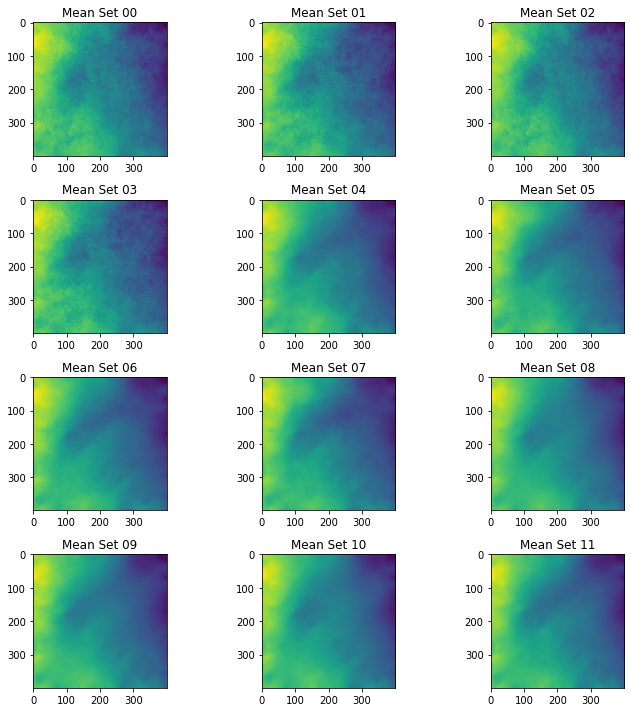

In [11]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(4,3,figsize=(10,10))
simu_nb=0
for i in range(len(all_results_mps)):
    plt.subplot(4,3,i+1)
    plt.imshow(all_results_mps[i].Mean[simu_nb])
    plt.title('Mean Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [12]:
fig[0].savefig('../images/mean_maps_MPS_test00.png')

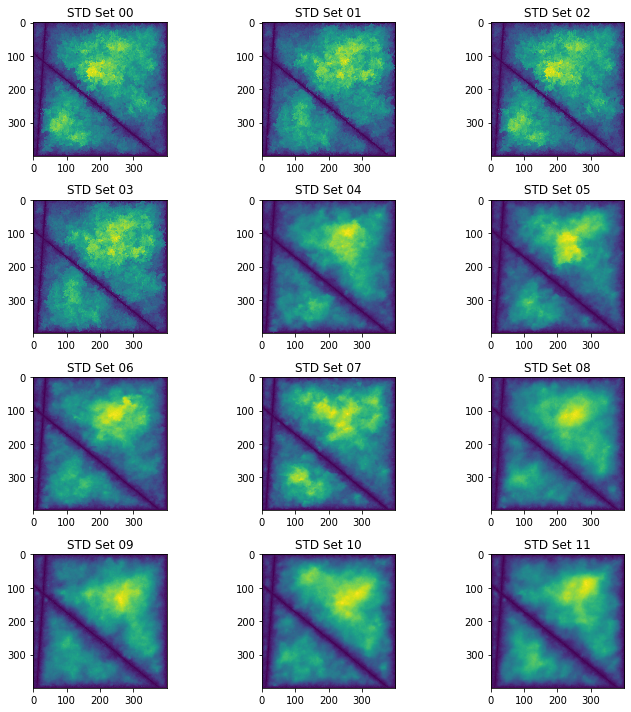

In [13]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(4,3,figsize=(10,10))
simu_nb = 0
for i in range(len(all_results_mps)):
    plt.subplot(4,3,i+1)
    plt.imshow(all_results_mps[i].Sd[simu_nb])
    plt.title('STD Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [94]:
fig[0].savefig('../images/std_maps_mps_test00.png')

### SGS simulations

In [14]:
path_sets_sgs = 'K:/projects/2019_tsanfleuron/output_simulation/800_3l_ss_bord/sgs/'
path_sets_sgs = '../simulation_outputs/800_3l_ss_bord/sgs/'
list_sets_sgs = sorted(os.listdir(path_sets_sgs))[:]
list_sets_sgs

['simulation_realisation00.pickle',
 'simulation_realisation01.pickle',
 'simulation_realisation02.pickle',
 'simulation_realisation03.pickle',
 'simulation_realisation04.pickle',
 'simulation_realisation05.pickle',
 'simulation_realisation06.pickle',
 'simulation_realisation07.pickle',
 'simulation_realisation08.pickle',
 'simulation_realisation09.pickle',
 'simulation_realisation10.pickle',
 'simulation_realisation11.pickle']

In [15]:
all_results_sgs = []
all_results_sgs.append(indice_dataframe(path_sets_sgs+'/'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:156: RuntimeWarning: invalid value encountered in true_divide


In [16]:
all_results_sgs[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,RealVolume
0,simulation_realisation00,"[[2569.7632, 2569.1992, 2568.8105, 2568.579, 2...",GRF,0.158078,7.928554,1.281849,"[[2569.76318359375, 2569.19921875, 2568.810546...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8727305.266067917, 8824695.64284969, 8129055....",8961644.0
1,simulation_realisation01,"[[2611.3545, 2610.4736, 2609.5251, 2608.9705, ...",GRF,0.664057,7.475268,1.384895,"[[2611.3544921875, 2610.4736328125, 2609.52514...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[9997012.912098486, 10168219.766682973, 965516...",10099488.0
2,simulation_realisation02,"[[2465.7305, 2465.3088, 2465.0427, 2464.927, 2...",GRF,1.692749,9.595590,1.615495,"[[2465.73046875, 2465.308837890625, 2465.04272...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14858531.472833231, 13963946.292750858, 14876...",15122563.0
3,simulation_realisation03,"[[2400.5906, 2400.1926, 2399.8137, 2399.409, 2...",GRF,-0.313805,8.888736,1.583905,"[[2400.590576171875, 2400.192626953125, 2399.8...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14399525.136283116, 14550229.104024451, 14172...",14120233.0
4,simulation_realisation04,"[[2440.6196, 2440.6907, 2440.63, 2440.4792, 24...",GRF,3.023718,10.028174,1.739231,"[[2440.61962890625, 2440.690673828125, 2440.62...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14717096.205193382, 13926015.62058601, 140240...",14846813.0
5,simulation_realisation05,"[[2393.1646, 2392.6743, 2391.9502, 2391.033, 2...",GRF,-0.944000,7.599327,1.649982,"[[2393.16455078125, 2392.67431640625, 2391.950...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[11741470.697023492, 12348860.237037312, 12344...",11884282.0
6,simulation_realisation06,"[[2494.662, 2494.6443, 2494.499, 2494.2515, 24...",GRF,0.458454,7.610211,1.348000,"[[2494.662109375, 2494.644287109375, 2494.4990...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[10691087.997370113, 10016356.292972552, 10215...",10465542.0
7,simulation_realisation07,"[[2462.3882, 2462.2322, 2461.9607, 2461.748, 2...",GRF,0.294745,7.695389,1.664760,"[[2462.38818359375, 2462.232177734375, 2461.96...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13350079.415372143, 13257144.856773837, 12996...",13047789.0
8,simulation_realisation08,"[[2483.8591, 2483.6965, 2483.56, 2483.4282, 24...",GRF,-3.187689,10.661611,1.944273,"[[2483.859130859375, 2483.696533203125, 2483.5...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[11821754.814590821, 12907648.848297691, 13399...",12439398.0
9,simulation_realisation09,"[[2444.2976, 2443.9978, 2443.6694, 2443.345, 2...",GRF,-3.079088,7.938430,1.826089,"[[2444.297607421875, 2443.997802734375, 2443.6...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13383849.027580142, 13095104.859652014, 13042...",12770030.0


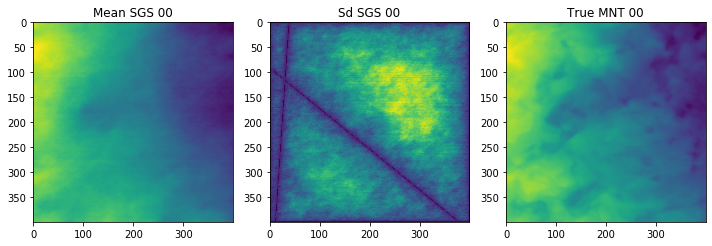

In [17]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(1,3,figsize=(10,10))
i=0
simu_nb=0

plt.subplot(1,3,1)
plt.imshow(all_results_sgs[i].Mean[simu_nb])
plt.title('Mean SGS {}'.format(str(i).zfill(2)))
plt.subplot(1,3,2)
plt.imshow(all_results_sgs[i].Sd[simu_nb])
plt.title('Sd SGS {}'.format(str(i).zfill(2)))
plt.subplot(1,3,3)
plt.imshow(all_results_sgs[i].TrueMNT[simu_nb])
plt.title('True MNT {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [18]:
fig[0].savefig('../images/sgs_test_noTrend00.png')

### Krig

In [19]:
path_sets_k = '../simulation_outputs/800_3l_ss_bord/krig/'
list_sets_k = sorted(os.listdir(path_sets_k))[:]
list_sets_k

['simulation_realisation00.pickle',
 'simulation_realisation01.pickle',
 'simulation_realisation02.pickle',
 'simulation_realisation03.pickle',
 'simulation_realisation04.pickle',
 'simulation_realisation05.pickle',
 'simulation_realisation06.pickle',
 'simulation_realisation07.pickle',
 'simulation_realisation08.pickle',
 'simulation_realisation09.pickle',
 'simulation_realisation10.pickle',
 'simulation_realisation11.pickle']

In [20]:
all_results_k = []
all_results_k.append(indice_dataframe(path_sets_k+'/',typeSimu='krig'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:128: RuntimeWarning: invalid value encountered in true_divide


In [21]:
all_results_k[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,RealVolume
0,simulation_realisation00,"[[2569.7632, 2569.1992, 2568.8105, 2568.579, 2...",KRIG,0.160946,3.249410,0.210516,"[[2569.76318359375, 2569.19921875, 2568.810546...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",8.936280e+06,8961644.0
1,simulation_realisation01,"[[2611.3545, 2610.4736, 2609.5251, 2608.9705, ...",KRIG,0.671023,3.758213,0.309929,"[[2611.3544921875, 2610.4736328125, 2609.52514...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9.993843e+06,10099488.0
2,simulation_realisation02,"[[2465.7305, 2465.3088, 2465.0427, 2464.927, 2...",KRIG,0.794186,5.244713,0.451907,"[[2465.73046875, 2465.308837890625, 2465.04272...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.499754e+07,15122563.0
3,simulation_realisation03,"[[2400.5906, 2400.1926, 2399.8137, 2399.409, 2...",KRIG,-0.308945,4.983171,0.448468,"[[2400.590576171875, 2400.192626953125, 2399.8...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.416891e+07,14120233.0
4,simulation_realisation04,"[[2440.6196, 2440.6907, 2440.63, 2440.4792, 24...",KRIG,2.888235,6.616740,0.693349,"[[2440.61962890625, 2440.690673828125, 2440.62...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.439215e+07,14846813.0
5,simulation_realisation05,"[[2393.1646, 2392.6743, 2391.9502, 2391.033, 2...",KRIG,-0.694045,4.588705,0.533964,"[[2393.16455078125, 2392.67431640625, 2391.950...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.199355e+07,11884282.0
6,simulation_realisation06,"[[2494.662, 2494.6443, 2494.499, 2494.2515, 24...",KRIG,0.896418,3.487709,0.289185,"[[2494.662109375, 2494.644287109375, 2494.4990...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.032437e+07,10465542.0
7,simulation_realisation07,"[[2462.3882, 2462.2322, 2461.9607, 2461.748, 2...",KRIG,-0.014968,4.566247,0.544159,"[[2462.38818359375, 2462.232177734375, 2461.96...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.305014e+07,13047789.0
8,simulation_realisation08,"[[2483.8591, 2483.6965, 2483.56, 2483.4282, 24...",KRIG,-3.305517,7.847088,0.847455,"[[2483.859130859375, 2483.696533203125, 2483.5...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.296033e+07,12439398.0
9,simulation_realisation09,"[[2444.2976, 2443.9978, 2443.6694, 2443.345, 2...",KRIG,-2.996392,5.175776,0.660203,"[[2444.297607421875, 2443.997802734375, 2443.6...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.324111e+07,12770030.0


In [22]:
plt.imshow(all_results_k[0]x)

SyntaxError: invalid syntax (<ipython-input-22-d2ac4028de5f>, line 1)

In [ ]:
minV = all_results_mps[0].TrueMNT.values[0].min()
maxV = all_results_mps[0].TrueMNT.values[0].max()
simu_nb  = 0
set_para = 10
fig = plt.subplots(1,4,figsize=(20,20))
plt.subplot(1,4,1)
plt.imshow(all_results_mps[0].TrueMNT.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('True MNT')
plt.subplot(1,4,2)
plt.imshow(all_results_mps[set_para].Mean.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('Mean MPS set param {}'.format(set_para))
plt.subplot(1,4,3)
plt.imshow(all_results_sgs[0].Mean.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('Mean SGS')
plt.subplot(1,4,4)
plt.imshow(all_results_k[0].Mean.values[simu_nb],vmin=minV,vmax=maxV)
plt.title('Kriging')
plt.show()



In [ ]:
fig[0].savefig('../images/meanSimu_{}.png'.format(simu_nb))

### Indice

In [ ]:
from colour import Color
red = Color("navy")
colors = list(red.range_to(Color("lightblue"),12))

In [ ]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_mps)):
    plt.plot(all_results_mps[i].Abs_error.values,label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)
    
plt.plot(all_results_sgs[0].Abs_error.values, label='SGS',color='green')
plt.plot(all_results_k[0].Abs_error.values, label='Kriging',color='tan')


plt.legend(loc=0)
plt.title('Absolute Error')
plt.xlabel('Test cases N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim()
plt.show()

In [107]:
fig.savefig('../images/abs_error.png')

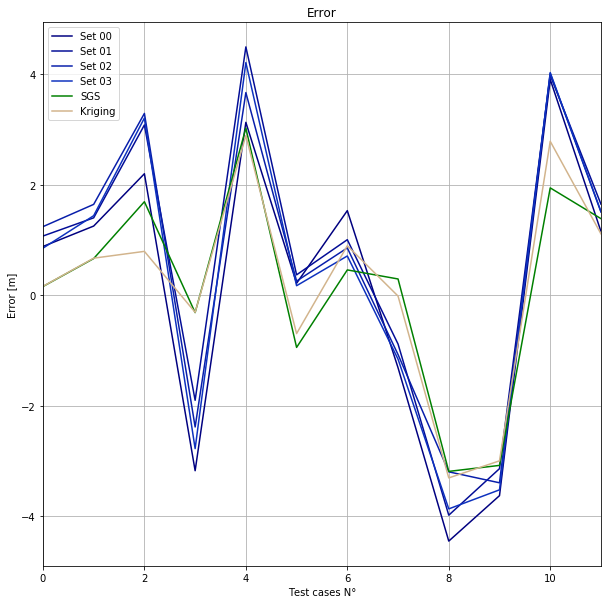

In [35]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_mps)):
    plt.plot(all_results_mps[i].Error.values,label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)
plt.plot(all_results_sgs[0].Error.values, label='SGS',color='green')
plt.plot(all_results_k[0].Error.values, label='Kriging',color='tan')

plt.legend(loc=0)

plt.title('Error')
plt.xlabel('Test cases N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [109]:
fig.savefig('../images/error.png')

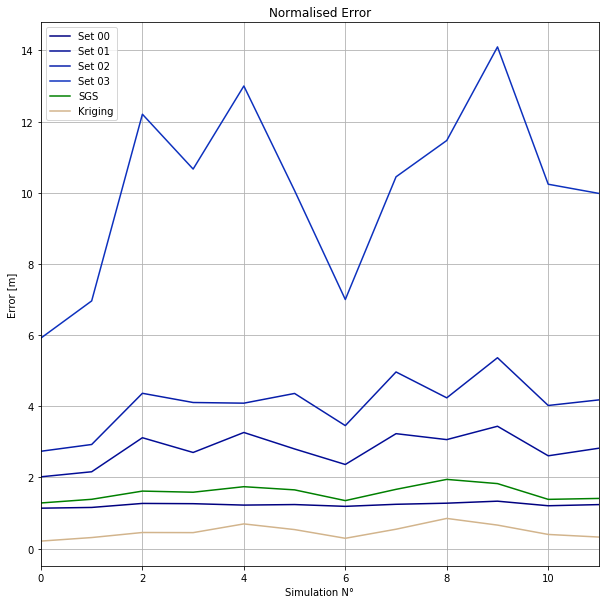

In [24]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_mps)):
    plt.plot(all_results_mps[i].Norm_Error.values,label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb )
plt.plot(all_results_sgs[0].Norm_Error.values, label='SGS',color='green')
plt.plot(all_results_k[0].Norm_Error.values, label='Kriging',color='tan')


plt.legend(loc=0)
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [111]:
fig.savefig('../images/norm_error.png')

In [26]:
import seaborn as sns
#sns.set(color_codes=True)

In [115]:
all_results_sgs[0]

,Sim_name,TrueMNT,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,RealVolume
0,simulation_realisation00,"[[2569.7632, 2569.1992, 2568.8105, 2568.579, 2...",GRF,0.158078,7.928554,1.281849,"[[2569.76318359375, 2569.19921875, 2568.810546...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8727305.266067917, 8824695.64284969, 8129055....",8961644.0
1,simulation_realisation01,"[[2611.3545, 2610.4736, 2609.5251, 2608.9705, ...",GRF,0.664057,7.475268,1.384895,"[[2611.3544921875, 2610.4736328125, 2609.52514...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[9997012.912098486, 10168219.766682973, 965516...",10099488.0
2,simulation_realisation02,"[[2465.7305, 2465.3088, 2465.0427, 2464.927, 2...",GRF,1.692749,9.595590,1.615495,"[[2465.73046875, 2465.308837890625, 2465.04272...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14858531.472833231, 13963946.292750858, 14876...",15122563.0
3,simulation_realisation03,"[[2400.5906, 2400.1926, 2399.8137, 2399.409, 2...",GRF,-0.313805,8.888736,1.583905,"[[2400.590576171875, 2400.192626953125, 2399.8...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14399525.136283116, 14550229.104024451, 14172...",14120233.0
4,simulation_realisation04,"[[2440.6196, 2440.6907, 2440.63, 2440.4792, 24...",GRF,3.023718,10.028174,1.739231,"[[2440.61962890625, 2440.690673828125, 2440.62...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14717096.205193382, 13926015.62058601, 140240...",14846813.0
5,simulation_realisation05,"[[2393.1646, 2392.6743, 2391.9502, 2391.033, 2...",GRF,-0.944000,7.599327,1.649982,"[[2393.16455078125, 2392.67431640625, 2391.950...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[11741470.697023492, 12348860.237037312, 12344...",11884282.0
6,simulation_realisation06,"[[2494.662, 2494.6443, 2494.499, 2494.2515, 24...",GRF,0.458454,7.610211,1.348000,"[[2494.662109375, 2494.644287109375, 2494.4990...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[10691087.997370113, 10016356.292972552, 10215...",10465542.0
7,simulation_realisation07,"[[2462.3882, 2462.2322, 2461.9607, 2461.748, 2...",GRF,0.294745,7.695389,1.664760,"[[2462.38818359375, 2462.232177734375, 2461.96...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13350079.415372143, 13257144.856773837, 12996...",13047789.0
8,simulation_realisation08,"[[2483.8591, 2483.6965, 2483.56, 2483.4282, 24...",GRF,-3.187689,10.661611,1.944273,"[[2483.859130859375, 2483.696533203125, 2483.5...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[11821754.814590821, 12907648.848297691, 13399...",12439398.0
9,simulation_realisation09,"[[2444.2976, 2443.9978, 2443.6694, 2443.345, 2...",GRF,-3.079088,7.938430,1.826089,"[[2444.297607421875, 2443.997802734375, 2443.6...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13383849.027580142, 13095104.859652014, 13042...",12770030.0


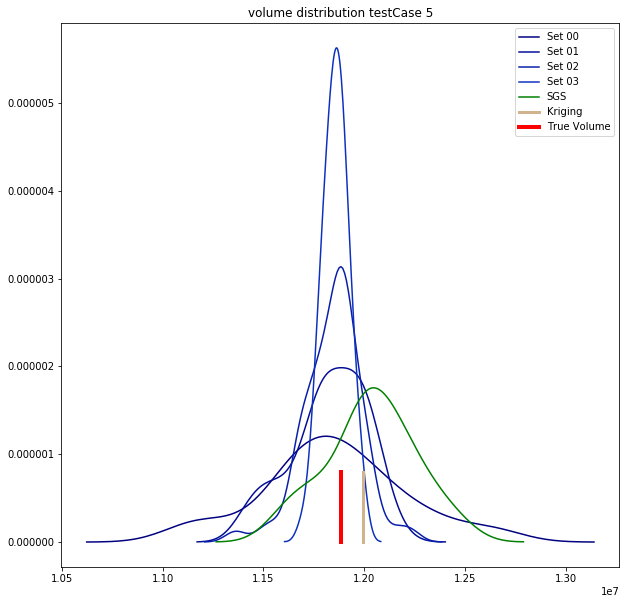

In [33]:
fig = plt.figure(figsize=(10,10))
simu_nb = 5
volumes = []

for i in range(len(all_results_mps)):
    volumes.append(all_results_mps[i].Volume.values[simu_nb])
        
    sns.distplot(volumes[i],hist=False, label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)
sns.distplot(all_results_sgs[0].Volume.values[simu_nb],hist=False,label='SGS', color='green')
plt.plot([all_results_k[0].Volume.values[simu_nb],all_results_k[0].Volume.values[simu_nb]],[0,0.0000008],label='Kriging',linewidth=3, color='tan')

    
#sns.distplot(np.mean(all_results_sgs[0].Volume.values),hist=False, label = 'Set {}'.format(str(i).zfill(2)),color=colors[i].rgb)

plt.plot([all_results_sgs[0].RealVolume.values[simu_nb],all_results_sgs[0].RealVolume.values[simu_nb]],[0,0.0000008],label='True Volume',linewidth=4,color='red')
plt.legend(loc=1)
plt.title('volume distribution testCase {}'.format(simu_nb))

plt.show()

In [34]:
fig.savefig('../images/volume_distribution.png')

In [42]:
for i in range(12):
    sns.distplot(all_results[0].Volume.values[i])
plt.plot([500000,500000],[0,0.00008],label='True Volume',linewidth=5)


NameError: name 'all_results' is not defined

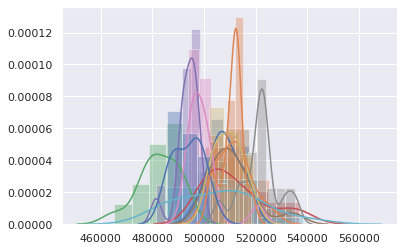

In [85]:
for i in range(12):
    sns.distplot(all_results[6].Volume.values[i])

Text(0.5, 0, 'Volume [m^2]')

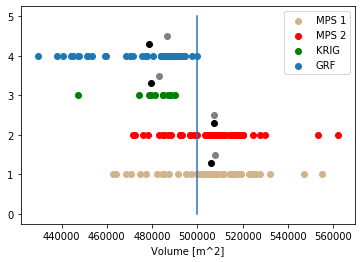

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')

## Kriging output

In [94]:
all_output = []
real_vol = []
type_sim = ['KRIG']
for name in simulation_name_krig:
    
    with open(path_output_krig+name,'rb') as file:
        trueMNT, simu_sets, mask_box_ti, position = pickle.load(file)

    if np.all(simu_sets != None):
        indice_out = indice_calculationV(trueMNT, simu_sets, 'krig')
        
        all_output.append([name[:-12], type_sim[0]] +indice_out)
        
        
results_frame_k = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:129: RuntimeWarning: invalid value encountered in true_divide


### OLD

Define the path of the data

In [2]:
path_output_krig = '../simulation_output_krig_set1/'
path_output_MPS  = '../simulation_output_set_trend_1/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name = os.listdir(path_output_MPS)
simulation_name_krig = sorted(simulation_name_krig)
simulation_name = sorted(simulation_name)

exec(open('../functions/03_indice_calculation_functions.py').read())


FileNotFoundError: [Errno 2] No such file or directory: '../simulation_output_krig_set1/'

In [3]:
simulation_name[0:3], simulation_name_krig[0:3]

(['realisation0_simu.pickle',
  'realisation1_simu.pickle',
  'realisation2_simu.pickle'],
 ['realisation0_krige.pickle',
  'realisation1_krige.pickle',
  'realisation2_krige.pickle'])

In [4]:
with open(path_output_MPS+simulation_name[4],'rb') as file:
    simus_sets = pickle.load(file)

trueMNT, trend_cut,[extr2,None,simGRF],mask[1], ref

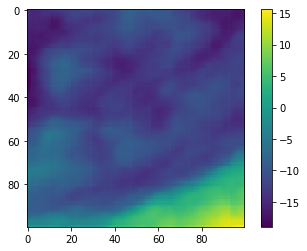

In [13]:
plt.imshow(simus_sets[0])
plt.colorbar()

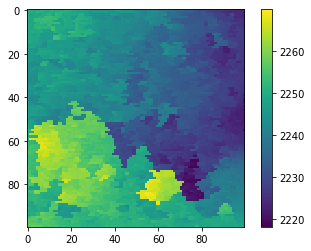

In [17]:
meanSS = np.add(simus_sets[1],simus_sets[2][0])
plt.imshow(meanSS[0])
plt.colorbar()

In [90]:
simus_sets[3]

array([2644, 2744,  791,  891])

In [91]:
a =[0,9]

In [92]:
np.all(a != None)

True

In [27]:
os.listdir('../')

['simulation_output_set_2',
 'Brouillon.ipynb',
 'simulation_trend',
 'generated_data',
 'real_data_cyprien',
 '.gitignore',
 '.ipynb_checkpoints',
 'simulation_output_krig_set1',
 'generated_data_test',
 'jupyter',
 'simulation_alexis',
 'old',
 'real_data',
 'simulation_output_set_trend_1',
 'data',
 'generated_data_old',
 '.git',
 'real_data_alexis',
 'simulation_output_set_1',
 'scripts',
 'functions',
 'README.md']

In [25]:
list_sets = ['set_1', 'set_2', 'set_trend_1']

In [20]:
all_output = []
real_vol = []
type_sim = ['MPS','GRF']
for name in simulation_name:
    
    with open(path_output_MPS+name,'rb') as file:
        trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)
        
    trueMNT += trend_cut
    for i, simus in enumerate(simu_sets):        
        if np.all(simus != None):
            
            simus = np.add(trend_cut, simus)

            indice_out = indice_calculationA(trueMNT, simus, 'mps')
        
            all_output.append([name[:-12], type_sim[i]]+indice_out)
        
        
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: invalid value encountered in true_divide


In [95]:
%xmode plain

Exception reporting mode: Plain


In [21]:
results_frame.head()

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,realisation0,MPS,-1.137077,3.473365,1.640604,"[[2292.2376098632812, 2291.9398193359375, 2292...","[[0.6354961329287337, 0.7535558192487, 1.26170...","[529913.2072753906, 519624.0041503906, 502368....",500000.0
1,realisation1,MPS,-0.809821,3.038069,1.434308,"[[2524.2253621419272, 2523.9181315104165, 2524...","[[1.2062203048612512, 1.1950727581098646, 1.36...","[509462.5642089844, 508942.0622558594, 512164....",500000.0
2,realisation2,MPS,-0.735828,3.422478,2.055130,"[[2150.6896362304688, 2150.8915201822915, 2150...","[[0.7870159685356458, 0.8745312305467324, 0.70...","[504601.732421875, 505222.9479980469, 506461.5...",500000.0
3,realisation3,MPS,-1.571266,5.550606,1.632712,"[[2308.6089680989585, 2308.3300984700522, 2308...","[[0.29112290034454436, 0.5815122236624358, 0.4...","[498774.00048828125, 504441.255859375, 497956....",500000.0
4,realisation4,MPS,1.752105,4.832653,2.234671,"[[2251.0850219726562, 2250.7294108072915, 2249...","[[0.4963154647772063, 0.4197275623948463, 2.65...","[474217.08935546875, 488717.57470703125, 47255...",500000.0


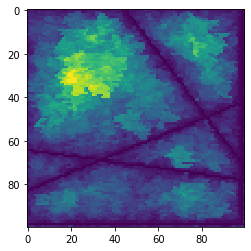

In [22]:
plt.imshow(results_frame.Sd[0])

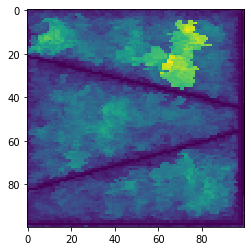

In [23]:
plt.imshow(results_frame.Sd[1])

In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

NameError: name 'results_frame_k' is not defined

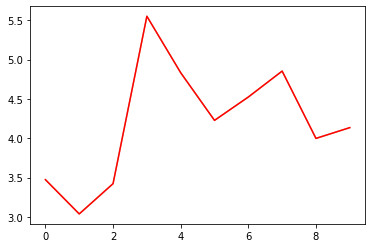

In [24]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Abs_error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Abs_error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Abs_error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

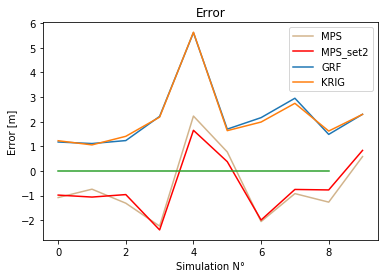

In [107]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

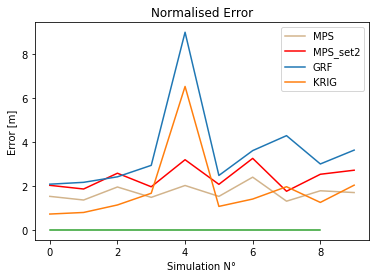

In [110]:
#etrange!!!!!!
plt.plot(results_frame[results_frame['Type']=='MPS'].Norm_Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Norm_Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Norm_Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


In [104]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS'].Volume.values[i][:])
    vol_MPS2.extend(results_frame_2[results_frame_2['Type']=='MPS'].Volume.values[i][:])

    #vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])
vol_KRIG.extend(results_frame_k[results_frame_k['Type']=='KRIG'].Volume.values)

    

Text(0.5, 0, 'Volume [m^2]')

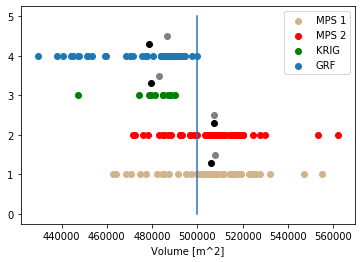

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')